In [6]:
import numpy as np
import matplotlib.pyplot as plt
from data_loader import data


X = data.T
X_centered = X - X.mean(axis=0)
print(f"Форма матриці даних: {X_centered.shape}", "\n")

Форма матриці даних: (9760, 64) 



In [7]:
covariance_matrix = X_centered.T @ X_centered / (X.shape[0] - 1)
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

eig_median = np.median(eigenvalues)
critical_threshold = eig_median * 10#10 just because, not much thought behind. may change upon request
eigenvalues_mask = eigenvalues[eigenvalues <= critical_threshold]


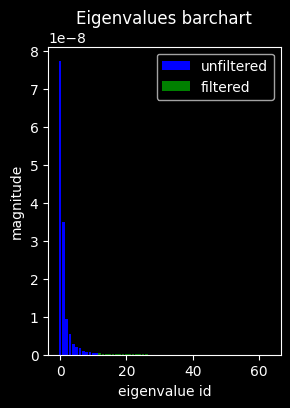

In [8]:
#barring (-_-) the eigenvalues
fig = plt.figure(figsize=(3, 4))
ax = fig.add_subplot(111)
ax.bar(range(len(eigenvalues)), eigenvalues[::-1], align='center', color='b', label="unfiltered")
ax.bar(range(len(eigenvalues) - len(eigenvalues_mask), len(eigenvalues)), eigenvalues_mask[::-1], color='g', label="filtered" )
ax.set_xlabel("eigenvalue id")
ax.set_ylabel("magnitude")
plt.legend()
plt.title("Eigenvalues barchart")
plt.show()

In [9]:
#PCA. change of base and projection
data_eig_base = X_centered @ eigenvectors
data_eig_base[: len(eigenvalues_mask):] = 0 #project onto non-principal hyperplane
X_cleaned = data_eig_base @ eigenvectors.T

print(X_cleaned.shape) #to check for potential errors

(9760, 64)


In [10]:
#FFT. Frequency decomposition
from data_loader import raw
channel_names = raw.info['ch_names'] #electrode code-names
fs = raw.info['sfreq'] #sampling frequency - [Hz] (aka data entry speed)
# print(channel_names)
target = 'O1' #resting state channel
target_id = channel_names.index(target)
target_data = X_cleaned[:, target_id]

N = len(target_data) #num of time samples
fft_values = np.fft.rfft(target_data)
fft_frequencies = np.fft.rfftfreq(N, 1/fs)
fft_power = np.abs(fft_values) ** 2





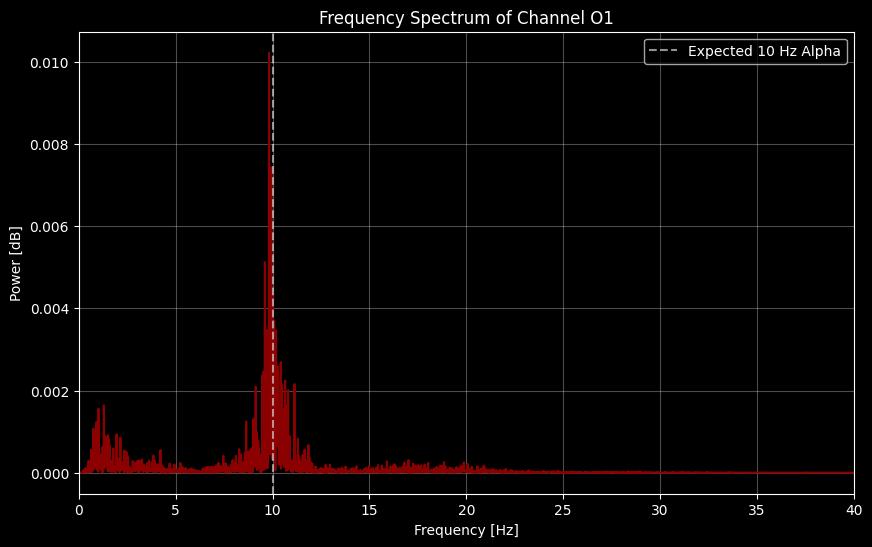

In [11]:
#Plotting the FFT
plt.figure(figsize=(10, 6))
plt.plot(fft_frequencies, fft_power, color='darkred')

plt.xlim(0, 40)
plt.axvline(x=10, color='lightgray', linestyle='--', alpha=0.7, label='Expected 10 Hz Alpha')

plt.xlabel("Frequency [Hz]")
plt.ylabel("Power [dB]")
plt.title('Frequency Spectrum of Channel O1')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()